In [1]:
import pymc as pm, polars as pl, arviz as az, numpy as np
from utils import extract_quantile_columns, standardize_columns, plot_trace

In [2]:
df = pl.read_csv("../../Rethinking_2/End_of_chapter_problems/data/Fish.csv", separator=";")

In [16]:
with pm.Model(coords={
    "livebait": df["livebait"].unique()
}) as model:
    # define data
    hours = pm.Data("hours", df["hours"].to_numpy())
    persons = pm.Data("persons", df["persons"].to_numpy())
    livebait = pm.Data("livebait", df["livebait"].to_numpy())

    # prior for poisson occurrence
    p_poisson = pm.Beta("poisson_occurence", alpha=2, beta=2)

    # prior or linear model
    alpha = pm.Normal("alpha", 0, 1, dims="livebait")
    b_persons = pm.Normal("b_persons",0 ,0.5)

    mu = alpha[livebait] + b_persons*persons + pm.math.log(hours)
    expected_occurrences = pm.Deterministic("expected_occurrences", pm.math.exp(mu))

    fish_caught = pm.ZeroInflatedPoisson("fish_caught", p_poisson, expected_occurrences, observed=df["fish_caught"].to_numpy())

    # Sample from posterior
    posterior = pm.sample(draws=1000, chains=4)
    posterior_predictive = pm.sample_posterior_predictive(posterior)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [poisson_occurence, alpha, b_persons]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.
Sampling: [alpha, fish_caught]


Output()

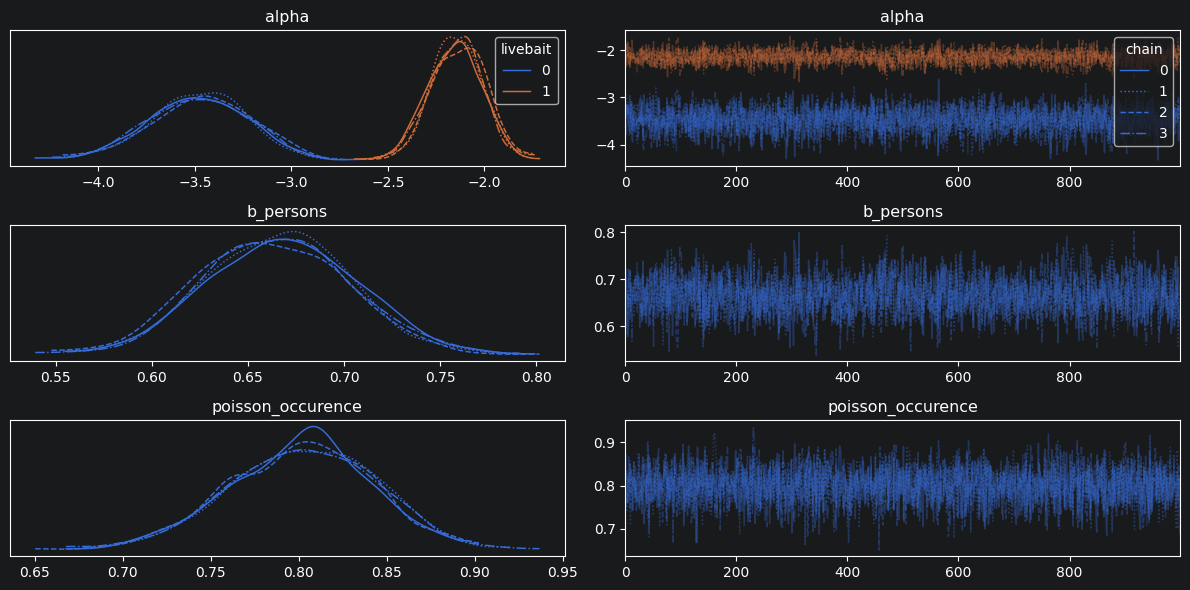

In [17]:
plot_trace(posterior, legend=True, var_names=["~expected_occurrences"])